## Insights Presentation

Well done on the previous task! As discussed during our call, I’m sending you further details.

You will need to create a presentation for our FMCG client, Nova Mart.

The client has requested visual charts along with key insights for specific business questions. Could you assist in generating the necessary visualizations using Python libraries such as Matplotlib, Seaborn, etc.?

Additionally, please prepare PowerPoint slides summarizing the key insights alongside the charts. This presentation will be essential in helping the client clearly communicate their findings.

Your specific task is described in `client_requests.pdf`. I would like this to be completed within the next 5 days.

### Instructions on how to submit and post on LinkedIn:


Create a video or audio presentation assuming you are presenting the insights to the client.

Create a LinkedIn post and attach the presentation you made. Tag Dhaval Patel, Hemanand Vadivel and Codebasics in your post.

Include the hashtag #codebasicsvirtualinternship in your post.

Check this sample LinkedIn post to get a clear idea: Post Link

After creating your post on LinkedIn, copy the Post Link of the post.

Navigate to the submission space provided for this assignment.

Paste the Post Link into the submission space.

Submit the assignment. (URL SUBMISSION)

**Create visuals and provide insights for the requested business questions below.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengatur konfigurasi visualisasi agar tampilan rapi dan estetik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# 2. Membaca dataset dari folder resources_2/datasets/
campaigns = pd.read_csv('resources_2/datasets/dim_campaigns.csv')
products = pd.read_csv('resources_2/datasets/dim_products.csv')
stores = pd.read_csv('resources_2/datasets/dim_stores.csv')
events = pd.read_csv('resources_2/datasets/fact_events.csv')

# 3. Menggabungkan seluruh tabel dimensi ke dalam tabel fakta penjualan (fact_events)
df = events.merge(campaigns, on='campaign_id', how='left') \
           .merge(products, on='product_code', how='left') \
           .merge(stores, on='store_id', how='left')

# 4. Menghitung metrik-metrik finansial dan operasional dasar:
# - Revenue Sebelum & Sesudah Promo (Harga * Kuantitas)
df['revenue_before'] = df['base_price(before_promo)'] * df['quantity_sold(before_promo)']
df['revenue_after'] = df['base_price(after_promo)'] * df['quantity_sold(after_promo)']

# - Incremental Sold Units (ISU) & Incremental Revenue (IR)
df['isu'] = df['quantity_sold(after_promo)'] - df['quantity_sold(before_promo)']
df['ir'] = df['revenue_after'] - df['revenue_before']


1. Visualize the number of stores in each city. Identify the city with the most stores
and explain the distribution of stores across other cities. How does the number of
stores in Bengaluru compare with those in Hyderabad and Chennai?
(Hint: Use a bar chart to visualize the number of stores by city)

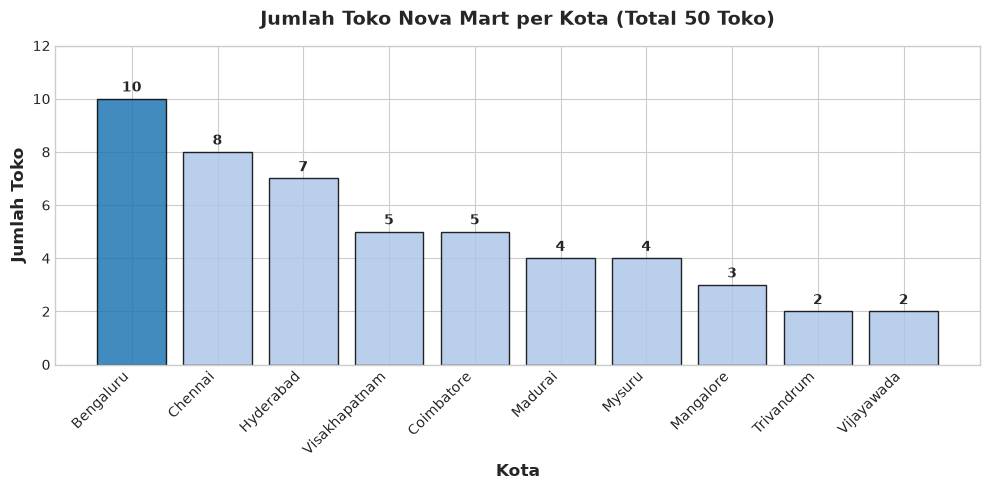

In [2]:
# 1. Menghitung jumlah toko unik di setiap kota dan mengurutkannya dari yang terbanyak
store_counts = stores['city'].value_counts().reset_index()
store_counts.columns = ['city', 'store_count']

# 2. Membuat visualisasi Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#1f77b4' if city == 'Bengaluru' else '#aec7e8' for city in store_counts['city']]
bars = plt.bar(store_counts['city'], store_counts['store_count'], color=colors, edgecolor='black', alpha=0.85)

# 3. Menambahkan label angka di atas setiap bar grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.15, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Jumlah Toko Nova Mart per Kota (Total 50 Toko)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kota', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Toko', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(store_counts['store_count']) + 2)
plt.tight_layout()
plt.show()


Business Insights:

1. Kota Terbanyak: Bengaluru memimpin dengan 10 toko.
2. Distribusi Toko: Konsentrasi terbesar ada di 3 kota metro utama (Bengaluru: 10, Chennai: 8, Hyderabad: 7), mencakup 50% dari total toko (25 dari 50 toko). Kota lainnya berkisar antara 2 hingga 5 toko.
3. Perbandingan: Bengaluru memiliki 25% lebih banyak toko dibandingkan Chennai (8 toko) dan ~43% lebih banyak dibanding Hyderabad (7 toko).

2. Analyze the total quantity sold after promotion for the Sankranti campaign across
different product categories. What percentage does each category contribute to
the overall sales, and what insights can be drawn from these contributions?
(Hint: Use a pie chart to visualize percentage contribution of each category to the overall sales)

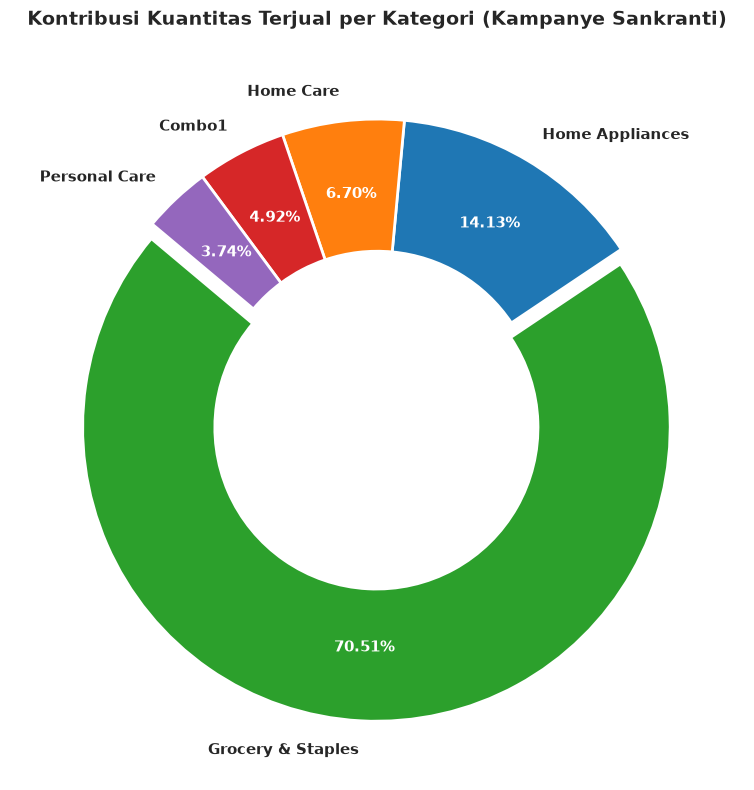

In [3]:
# 1. Filter data khusus untuk kampanye 'Sankranti'
sankranti_df = df[df['campaign_name'] == 'Sankranti']

# 2. Agregasikan total kuantitas penjualan setelah promosi (quantity_sold(after_promo)) berdasarkan kategori produk
category_sales = sankranti_df.groupby('category')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)

# 3. Hitung kontribusi persentase dari masing-masing kategori
category_pct = (category_sales / category_sales.sum()) * 100

# 4. Membuat visualisasi Pie Chart (Donut Chart)
plt.figure(figsize=(8, 8))
colors_pie = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
explode = [0.05, 0, 0, 0, 0]  # Menyorot kategori kontributor terbesar

wedges, texts, autotexts = plt.pie(
    category_sales, 
    labels=category_sales.index, 
    autopct='%1.2f%%',
    startangle=140, 
    colors=colors_pie,
    explode=explode,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=11, weight="bold", color="white")
plt.setp(texts, size=11, weight="bold")
plt.title('Kontribusi Kuantitas Terjual per Kategori (Kampanye Sankranti)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


Business Insights:
1. Dominasi Mutlak: Kategori Grocery & Staples menyumbang 70,51% (177.724 unit) dari total penjualan kampanye Sankranti.
2. Kategori lainnya: Home Appliances (14,13%), Home Care (6,70%), Combo1 (4,92%), dan Personal Care (3,74%).
3. Insight Strategis: Festival Sankranti identik dengan persiapan perayaan dan kebutuhan pangan rumah tangga, sehingga promosi pada produk kebutuhan pokok paling efektif menarik minat belanja massal.

3. Examine the correlation between base price (after the promotion) and sales
quantities (after the promotion). What insights can be drawn regarding the
relationship between base price and sales quantities after the promotion?
(Hint: Use heatmap to get the correlation)

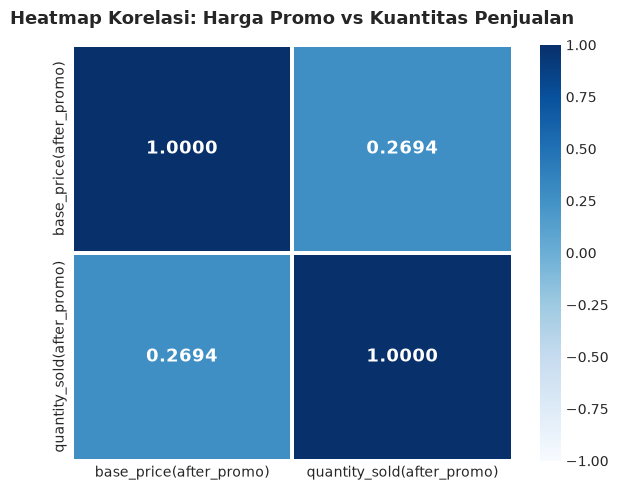

In [4]:
# 1. Mengambil kolom 'base_price(after_promo)' dan 'quantity_sold(after_promo)'
price_qty_corr = df[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()

# 2. Membuat visualisasi Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    price_qty_corr, 
    annot=True, 
    fmt='.4f', 
    cmap='Blues', 
    vmin=-1, 
    vmax=1, 
    cbar=True,
    linewidths=1.5,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title('Heatmap Korelasi: Harga Promo vs Kuantitas Penjualan', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


Business Insights:
1. Koefisien korelasi bernilai +0.2694 (korelasi positif lemah).
2. Interpretasi Bisnis: Kuantitas penjualan tidak hanya bergantung pada murahnya harga nominal. Produk berharga tinggi (seperti paket Combo seharga 2.500) tetap mencatatkan volume penjualan sangat tinggi karena adanya skema promosi menarik (seperti Cashback ₹500).

4. Analyze the distribution of quantity sold before the promotion for each product
category (Grocery & Staples, Home Care, Personal Care, Home Appliances,
etc.). What patterns or trends do you observe across these categories, and how
could these insights inform future promotional strategies?
(Hint: Use individual histograms to visualize the distribution)

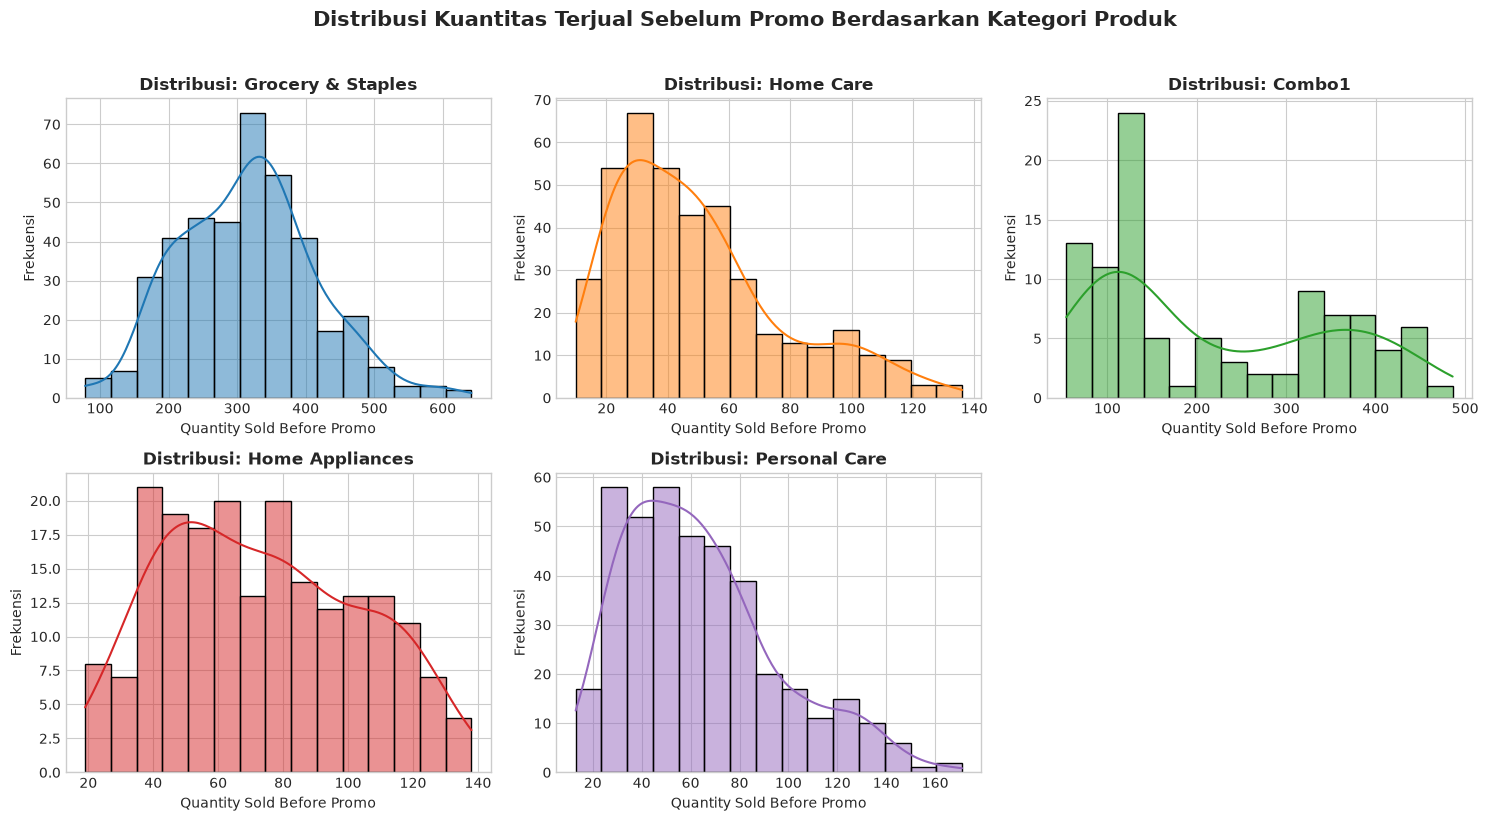

In [5]:
# 1. Mendapatkan daftar seluruh kategori produk unik
categories = df['category'].unique()

# 2. Membuat individual histograms dalam subplot 2 baris x 3 kolom
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 3. Looping untuk menggambar histogram setiap kategori
for i, cat in enumerate(categories):
    cat_data = df[df['category'] == cat]['quantity_sold(before_promo)']
    sns.histplot(cat_data, bins=15, kde=True, ax=axes[i], color=palette[i % len(palette)], edgecolor='black')
    axes[i].set_title(f'Distribusi: {cat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quantity Sold Before Promo', fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)

# Sembunyikan subplot ke-6 yang tidak terpakai
if len(categories) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Distribusi Kuantitas Terjual Sebelum Promo Berdasarkan Kategori Produk', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Business Insights:
1. Pola Fast-Moving: Grocery & Staples memiliki baseline penjualan normal tertinggi (rata-rata 314,8 unit).
2. Pola Slow-Moving: Personal Care (rata-rata 63,8 unit) dan Home Care (rata-rata 49,6 unit) memiliki baseline rendah.
3. Rekomendasi Strategi: Kategori dengan baseline rendah butuh promo berbasis kuantitas (seperti BOGOF) agar pelanggan terdorong membeli lebih banyak (stocking up), sedangkan produk kebutuhan pokok cukup didorong dengan diskon ringan.

5. Analyze the incremental sold units percentage (ISU%) across various cities.
Identify the city with the highest ISU% after the promotion and the city with the
smallest change. What trends can be observed about the effectiveness of
codebasics.io
promotions in driving sales across these cities?
(Hint: Use a line chart to visualize the ISU% comparison across cities)

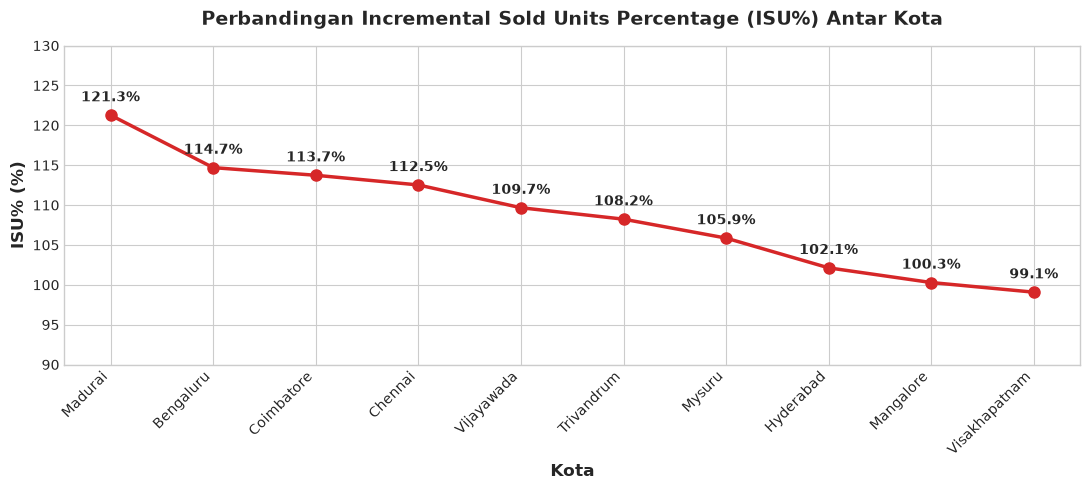

In [6]:
# 1. Menghitung total kuantitas sebelum dan sesudah promosi untuk setiap kota
city_isu = df.groupby('city').agg(
    total_qty_before=('quantity_sold(before_promo)', 'sum'),
    total_qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

# 2. Menghitung formula ISU% per kota: ((Qty_after - Qty_before) / Qty_before) * 100
city_isu['ISU%'] = (
    ((city_isu['total_qty_after'] - city_isu['total_qty_before']) / 
     city_isu['total_qty_before']) * 100
)

# 3. Mengurutkan kota berdasarkan ISU% tertinggi ke terendah
city_isu_sorted = city_isu.sort_values(by='ISU%', ascending=False).reset_index(drop=True)

# 4. Membuat visualisasi Line Chart
plt.figure(figsize=(11, 5))
plt.plot(city_isu_sorted['city'], city_isu_sorted['ISU%'], marker='o', linewidth=2.5, markersize=8, color='#d62728')

# Menambahkan anotasi nilai persentase pada setiap titik garis
for i, row in city_isu_sorted.iterrows():
    plt.annotate(
        f"{row['ISU%']:.1f}%", 
        (row['city'], row['ISU%']),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('Perbandingan Incremental Sold Units Percentage (ISU%) Antar Kota', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kota', fontsize=12, fontweight='bold')
plt.ylabel('ISU% (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(90, 130)
plt.tight_layout()
plt.show()


Business Insights:
1. ISU% Tertinggi: Madurai (121,28%), disusul Bengaluru (114,70%) dan Coimbatore (113,74%).
2. Perubahan Terkecil: Visakhapatnam (99,07%).
Tren Efektivitas: Promosi berhasil melipatgandakan volume penjualan di seluruh kota (seluruh kota mencatatkan pertumbuhan unit $\ge 99%$).

6. Analyze the relationship between incremental revenue and incremental sold units
for different promotion types in Hyderabad. Which promotion type led to the
highest incremental sold units, and which one generated the highest incremental
revenue? What insights can you draw from the balance between the two metrics
for this city?
(Hint: Use a scatter plot to analyze the relationship)

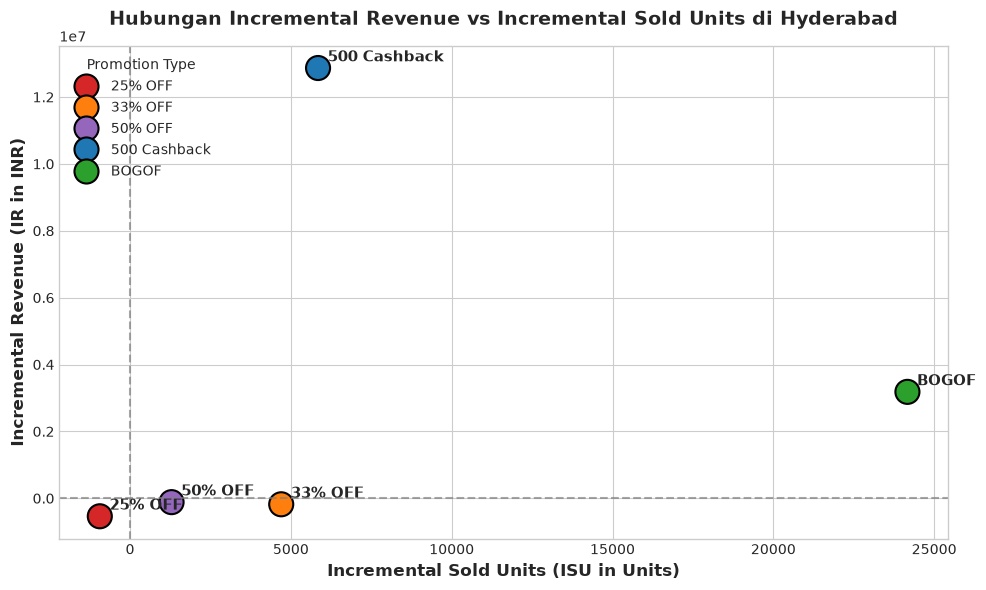

In [7]:
# 1. Filter data transaksi khusus untuk kota 'Hyderabad'
hyd_df = df[df['city'] == 'Hyderabad']

# 2. Agregasikan Incremental Sold Units (ISU) dan Incremental Revenue (IR) berdasarkan tipe promo
hyd_promo = hyd_df.groupby('promo_type').agg(
    total_isu=('isu', 'sum'),
    total_ir=('ir', 'sum')
).reset_index()

# 3. Membuat visualisasi Scatter Plot
plt.figure(figsize=(10, 6))
palette_promo = {'BOGOF': '#2ca02c', '500 Cashback': '#1f77b4', '33% OFF': '#ff7f0e', '50% OFF': '#9467bd', '25% OFF': '#d62728'}

sns.scatterplot(
    data=hyd_promo, 
    x='total_isu', 
    y='total_ir', 
    hue='promo_type', 
    palette=palette_promo,
    s=300, 
    edgecolor='black',
    linewidth=1.5
)

# Menambahkan label teks untuk setiap titik di grafik
for _, row in hyd_promo.iterrows():
    plt.text(
        row['total_isu'] + 300, 
        row['total_ir'] + 200000, 
        row['promo_type'], 
        fontsize=11, 
        fontweight='bold'
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)

plt.title('Hubungan Incremental Revenue vs Incremental Sold Units di Hyderabad', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Incremental Sold Units (ISU in Units)', fontsize=12, fontweight='bold')
plt.ylabel('Incremental Revenue (IR in INR)', fontsize=12, fontweight='bold')
plt.legend(title='Promotion Type', loc='upper left')
plt.tight_layout()
plt.show()


Business Insights:
1. Unit Tertinggi: BOGOF menghasilkan kenaikan unit terbesar (+24.168 unit).
2. Revenue Tertinggi: 500 Cashback menghasilkan lonjakan omzet terbesar (+₹12.866.500).
3. Keseimbangan: BOGOF sangat cocok untuk mengosongkan gudang/stok, sedangkan 500 Cashback paling efektif memaksimalkan pemasukan kas. Sebaliknya, promo 25% OFF terbukti merugikan di Hyderabad karena unit dan revenue keduanya turun.

7. Analyze the revenue before and after promotions across different product
categories in Bengaluru. What trends can be identified in the performance of
each category, and how did promotions impact overall revenue in the city?
(Hint: Use a vertical bar chart to compare the revenue before and after promotions)

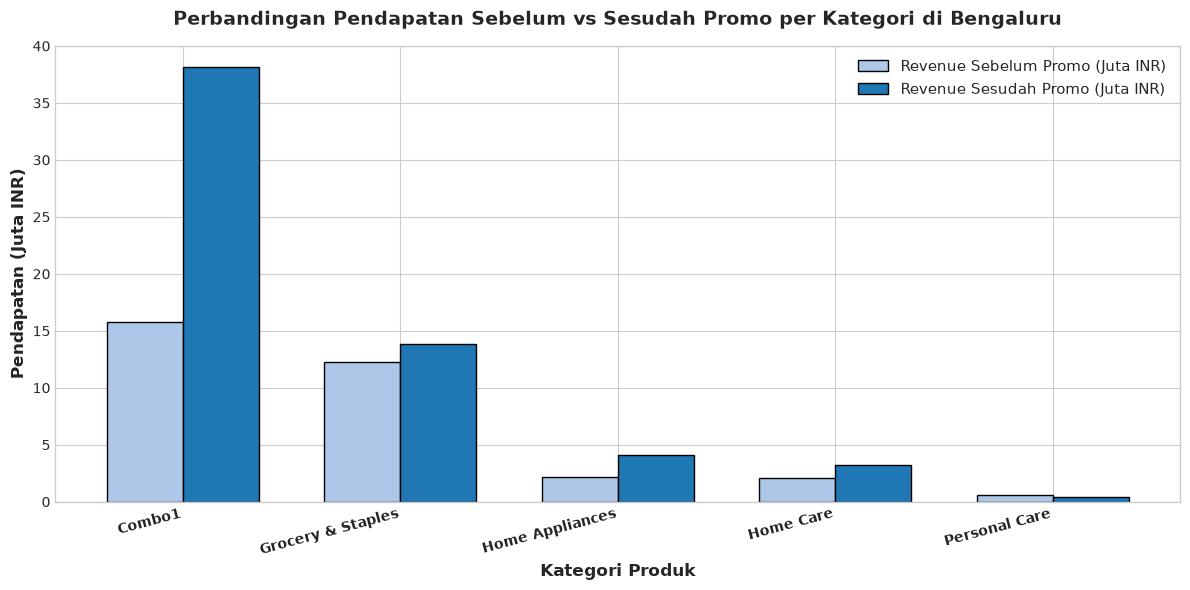

In [8]:
# 1. Filter data khusus untuk kota 'Bengaluru'
blr_df = df[df['city'] == 'Bengaluru']

# 2. Agregasikan total revenue sebelum dan sesudah promo untuk setiap kategori produk
blr_cat = blr_df.groupby('category').agg(
    rev_before=('revenue_before', 'sum'),
    rev_after=('revenue_after', 'sum')
).reset_index()

# 3. Hitung pertumbuhan pendapatan absolut dan persentasenya
blr_cat['revenue_growth'] = blr_cat['rev_after'] - blr_cat['rev_before']
blr_cat['growth_%'] = (blr_cat['revenue_growth'] / blr_cat['rev_before']) * 100

# 4. Membuat visualisasi Grouped Vertical Bar Chart
x = np.arange(len(blr_cat['category']))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, blr_cat['rev_before'] / 1e6, width, label='Revenue Sebelum Promo (Juta INR)', color='#aec7e8', edgecolor='black')
plt.bar(x + width/2, blr_cat['rev_after'] / 1e6, width, label='Revenue Sesudah Promo (Juta INR)', color='#1f77b4', edgecolor='black')

plt.title('Perbandingan Pendapatan Sebelum vs Sesudah Promo per Kategori di Bengaluru', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Produk', fontsize=12, fontweight='bold')
plt.ylabel('Pendapatan (Juta INR)', fontsize=12, fontweight='bold')
plt.xticks(x, blr_cat['category'], rotation=15, ha='right', fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Business Insights:
1. Total omzet di Bengaluru naik drastis dari ₹32,91 Juta menjadi ₹59,68 Juta (naik +81,35%).
2. Kategori Combo1 menjadi kontributor pertumbuhan moneter terbesar (+141,65% atau bertambah ₹22,35 Juta), disusul Home Appliances (+88,35%).
3. Kategori Personal Care mengalami penurunan pendapatan (-32,39%), yang menandakan bahwa strategi promosi untuk kategori ini perlu dievaluasi ulang.

Key Metrics:
</br>● IR% (Incremental Revenue): IR% measures the percentage change in revenue
after a promotion compared to the revenue before the promotion. It helps assess
how effective a promotion was in driving revenue growth.
</br>● ISU% (Incremental Sold Units): ISU% calculates the percentage change in the
number of units sold after a promotion compared to the units sold before the
promotion. It indicates the effectiveness of a promotion in boosting sales volume